In [1]:
import numpy as np
from tqdm import tqdm
from reinforce import reinforce
import matplotlib.pyplot as plt
from short_corridor import ShortCorridorEnv

In [2]:
def experiment(
    env:ShortCorridorEnv,
    alpha:float,
    runs:int=100,
    episodes:int=1000,
    gamma:float=1.0
):
    rewards_per_episode = np.zeros(episodes)

    for _ in tqdm(range(runs), leave=False):
        theta = np.array([-1.47, 1.47])
        res = reinforce(
            env=env,
            episodes=episodes,
            theta=theta,
            alpha=alpha,
            gamma=gamma
        )
        rewards_per_episode += res['rewards_per_episode']
    rewards_per_episode /= runs
    return rewards_per_episode


In [3]:
alphas = [2**-12, 2**-13, 2**-14]
rpe = []
env = ShortCorridorEnv(truncate=200)

runs = 100
episodes = 1000
gamma = 1.0

for alpha in alphas:
    rpe.append(experiment(
        env=env,
        alpha=alpha,
        runs=runs,
        episodes=episodes,
        gamma=gamma
    ))
    print(alpha, "is done!")

0.000244140625 is done!


0.0001220703125 is done!


6.103515625e-05 is done!


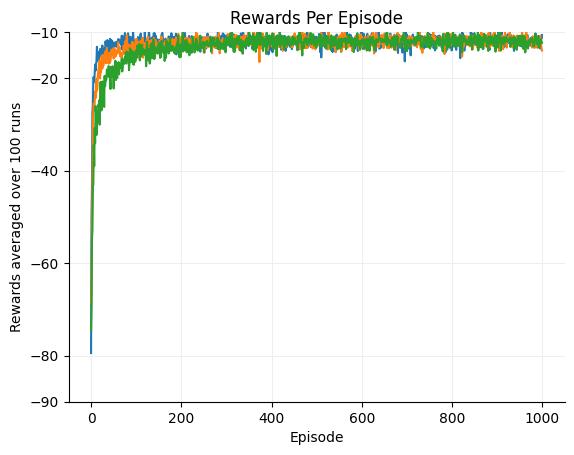

In [4]:
fig = plt.figure()
ax = plt.subplot(111)

for i in range(len(alphas)):
    ax.plot(rpe[i], label=alphas[i])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(c="#eee")
ax.set_ylim([-90, -10])
ax.set_yticks([-10, -20, -40, -60, -80, -90])
ax.set_xlabel("Episode")
ax.set_ylabel("Rewards averaged over 100 runs")
ax.set_title("Rewards Per Episode");